<a href="https://colab.research.google.com/github/JustinStutler/sarkar-computer-vision-lectures/blob/main/CV_Module_4_2_Point_features_and_descriptors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 4.2 HW
Justin Stutler

# Imports

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

print(cv2.__version__)
np.set_printoptions(precision=2, suppress=True)

5.0.0


# Load Images

In [15]:
from google.colab import drive
drive.mount('/content/drive')
data_dir = '/content/drive/MyDrive/4.2 Photos/'
!ls "$data_dir"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
10.jpg	12.jpg	14.jpg	16.jpg	2.jpg  4.jpg  6.jpg  8.jpg
11.jpg	13.jpg	15.jpg	1.jpg	3.jpg  5.jpg  7.jpg  9.jpg


## Display Images

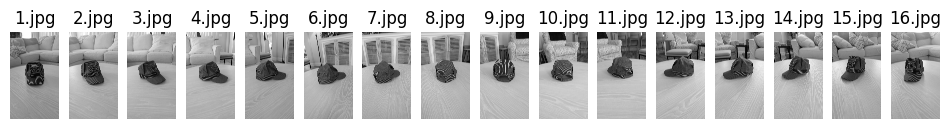

In [27]:
fig, ax = plt.subplots(1, 16, figsize=(12, 6))
fig.set_size_inches(12, 18)
i = 1
while i < 17:
  img = cv2.imread(data_dir + str(i) +'.jpg')
  img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  ax[i-1].imshow(img, cmap = 'gray')
  ax[i-1].set_title(str(i) + '.jpg')
  ax[i-1].axis('off')
  i = i + 1

# Core

## Load 2 Images and convert to Grayscale

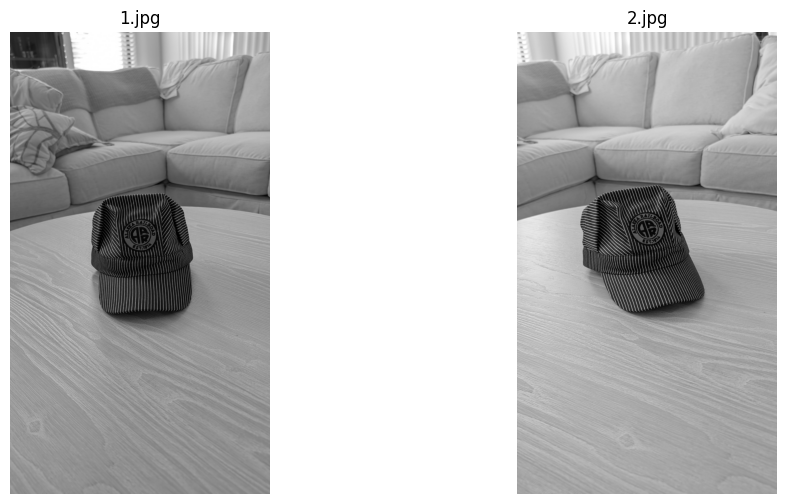

In [4]:
# Load your first two photos
image_1 = cv2.imread(data_dir + '1.jpg')
image_2 = cv2.imread(data_dir + '2.jpg')

# Check that both images loaded
assert image_1 is not None, "Could not load 1.jpg. Check data_dir."
assert image_2 is not None, "Could not load 2.jpg. Check data_dir."

# Convert to grayscale
image_1 = cv2.cvtColor(image_1, cv2.COLOR_BGR2GRAY)
image_2 = cv2.cvtColor(image_2, cv2.COLOR_BGR2GRAY)

# Show both images
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(image_1, cmap='gray')
ax[0].set_title('1.jpg')
ax[0].axis('off')

ax[1].imshow(image_2, cmap='gray')
ax[1].set_title('2.jpg')
ax[1].axis('off')

plt.show()

## Find and Match SIFT Features

Keypoints in 1.jpg: 23982
Keypoints in 2.jpg: 25013
Total cross-checked matches: 5534


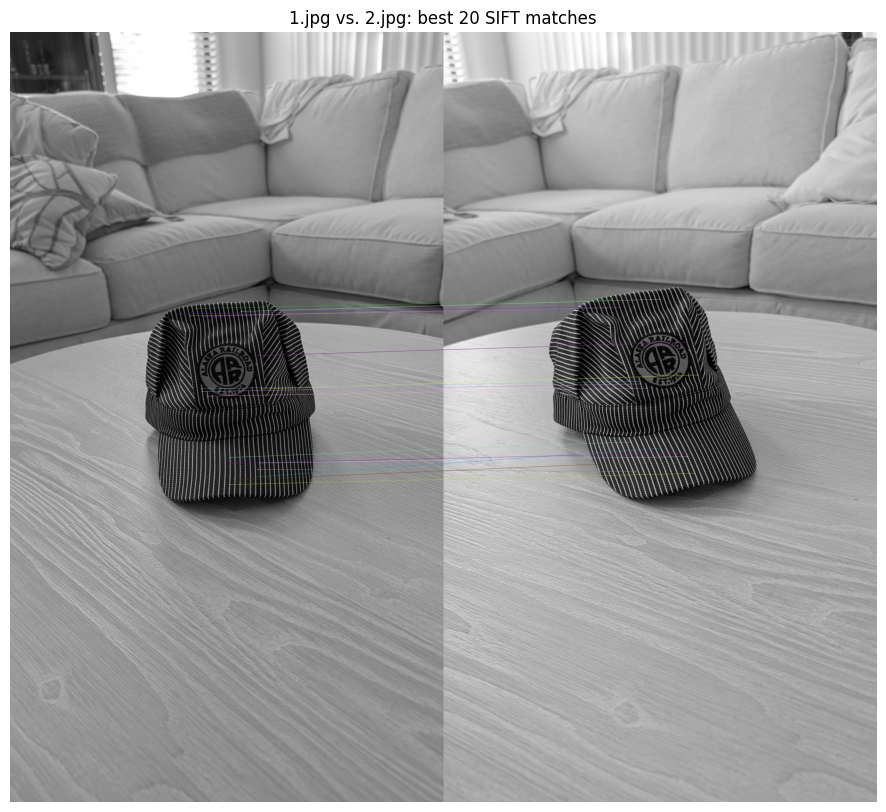

In [5]:
# 1. Find keypoints and descriptors in both photos
sift = cv2.SIFT_create()

keypoints_1, descriptors_1 = sift.detectAndCompute(image_1, None)
keypoints_2, descriptors_2 = sift.detectAndCompute(image_2, None)

# 2. Confirm that SIFT found features
assert descriptors_1 is not None, "No SIFT features found in 1.jpg."
assert descriptors_2 is not None, "No SIFT features found in 2.jpg."

# 3. Match descriptors using the notebook's method
bf = cv2.BFMatcher(cv2.NORM_L1, crossCheck=True)
matches = bf.match(descriptors_1, descriptors_2)

# 4. Put the closest descriptor matches first
matches = sorted(matches, key=lambda match: match.distance)

# 5. Print initial measurements
print(f"Keypoints in 1.jpg: {len(keypoints_1)}")
print(f"Keypoints in 2.jpg: {len(keypoints_2)}")
print(f"Total cross-checked matches: {len(matches)}")

# 6. Draw up to 20 best matches
best_matches = matches[:20]

match_image = cv2.drawMatches(
    image_1, keypoints_1,
    image_2, keypoints_2,
    best_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(16, 10))
plt.imshow(cv2.cvtColor(match_image, cv2.COLOR_BGR2RGB))
plt.title(f"1.jpg vs. 2.jpg: best {len(best_matches)} SIFT matches")
plt.axis("off")
plt.show()

## Check Match Quality

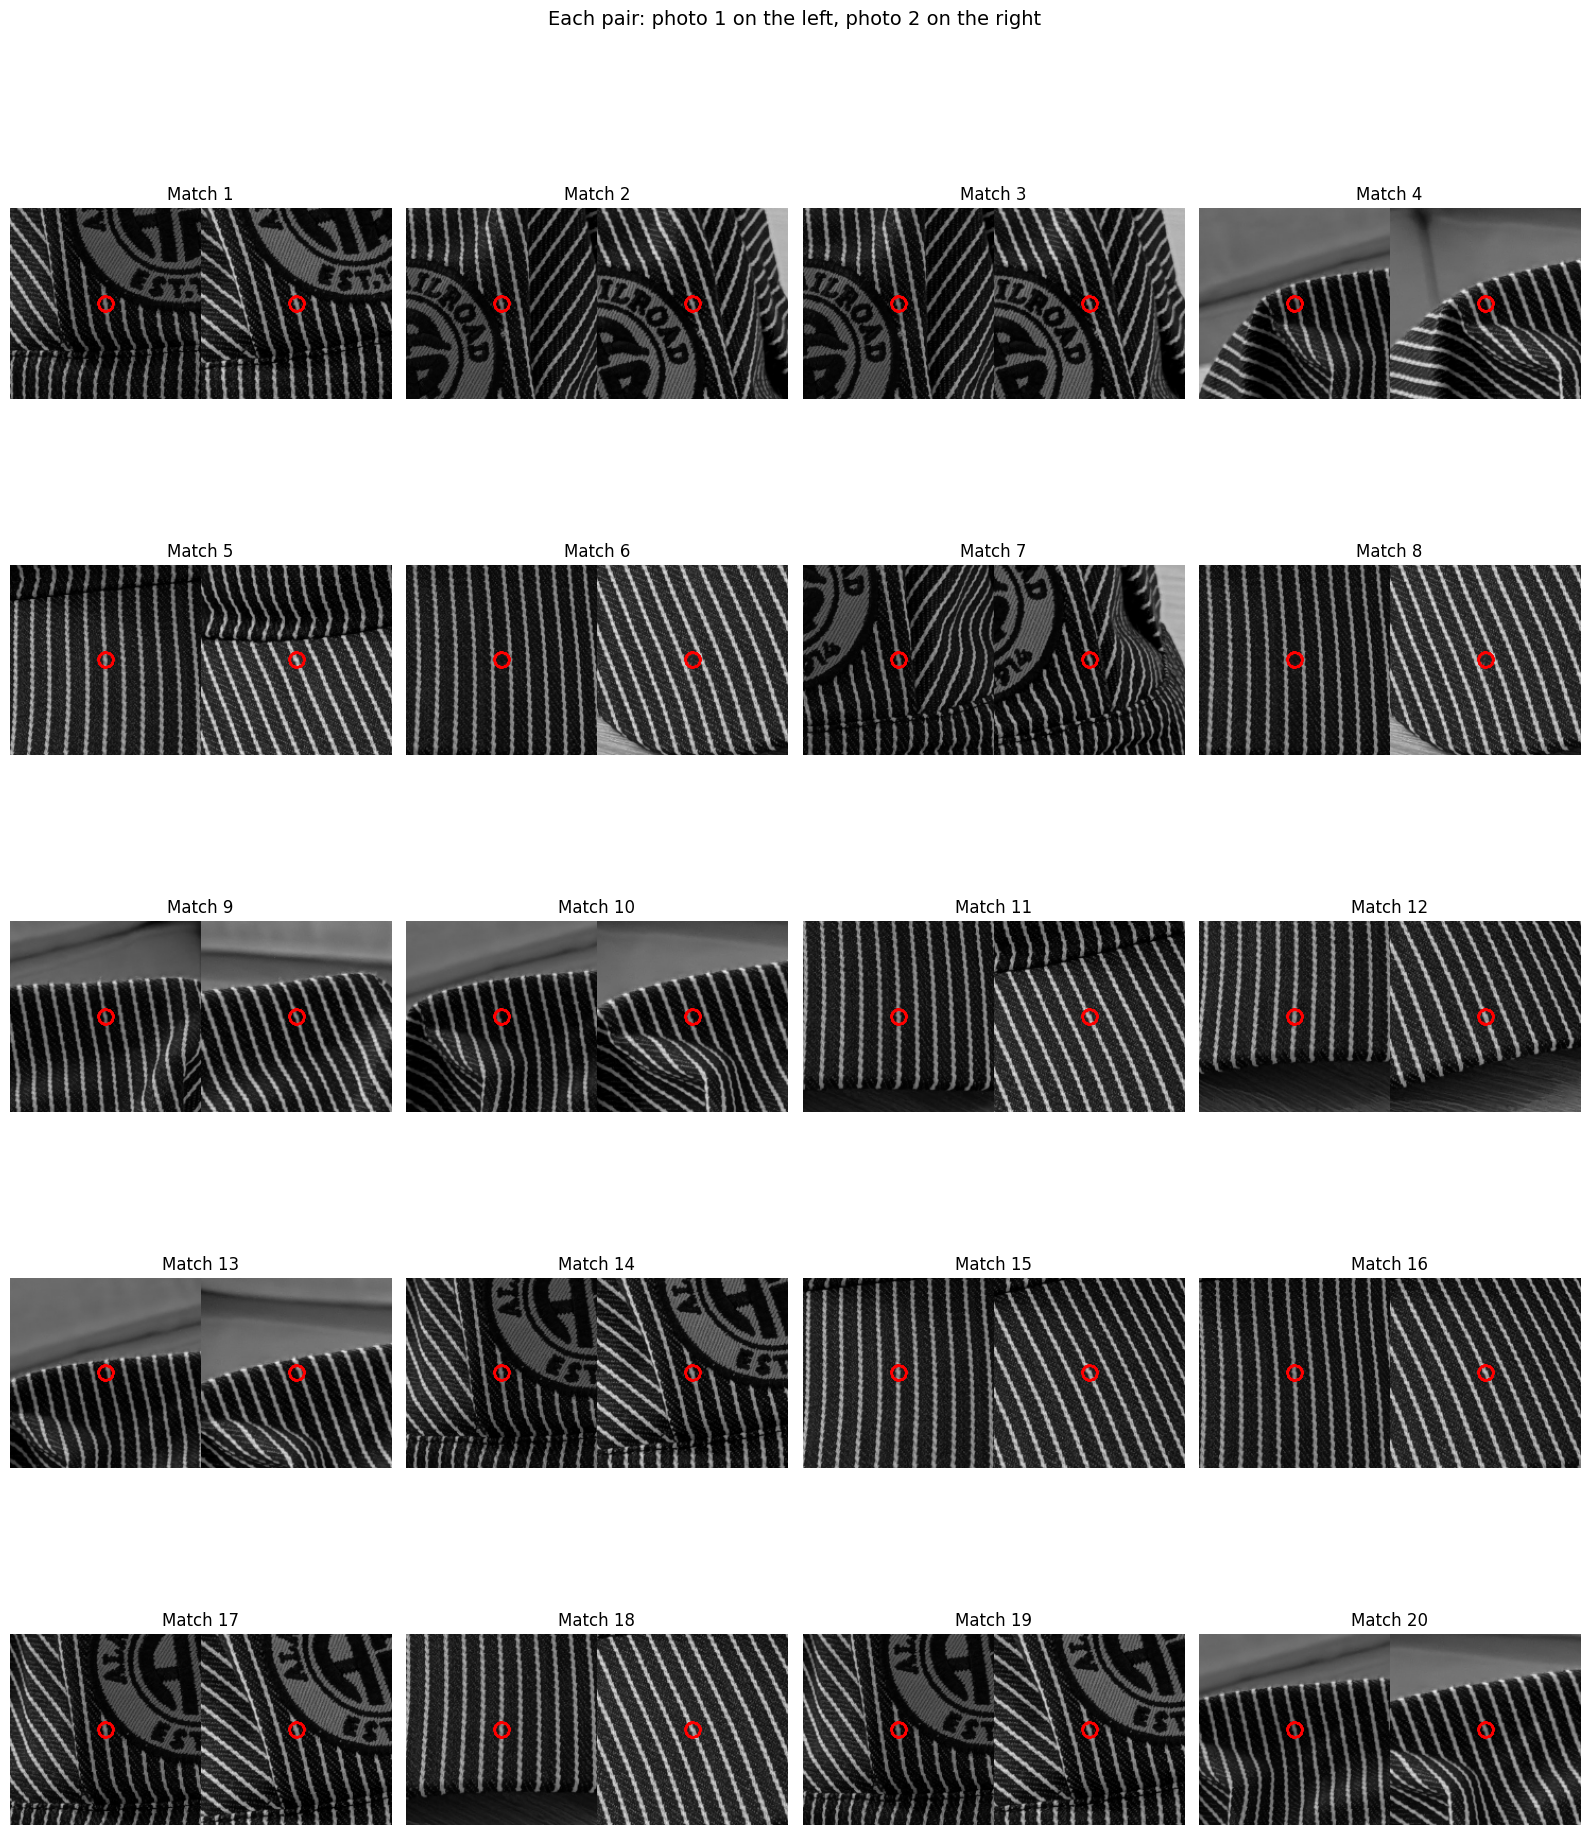

In [6]:
# Inspect the top 20 matches individually
matches_to_check = matches[:20]

fig, axes = plt.subplots(5, 4, figsize=(16, 20))
axes = axes.ravel()

for index, ax in enumerate(axes):
    if index >= len(matches_to_check):
        ax.axis("off")
        continue

    match = matches_to_check[index]

    # Coordinates of the matched points
    x1, y1 = keypoints_1[match.queryIdx].pt
    x2, y2 = keypoints_2[match.trainIdx].pt

    # Show a neighborhood around each point
    patches = []

    for image, x, y in [
        (image_1, x1, y1),
        (image_2, x2, y2)
    ]:
        # Use the same relative viewing window for each photo
        radius = max(20, int(min(image.shape) * 0.06))
        x, y = int(round(x)), int(round(y))

        patch = cv2.getRectSubPix(
            image, (2 * radius + 1, 2 * radius + 1),
            (float(x), float(y))
        )

        patch = cv2.cvtColor(patch, cv2.COLOR_GRAY2RGB)
        patch = cv2.resize(patch, (180, 180))

        # Mark the matched location at the center
        cv2.circle(patch, (90, 90), 7, (255, 0, 0), 2)
        patches.append(patch)

    ax.imshow(np.hstack(patches))
    ax.set_title(f"Match {index + 1}")
    ax.axis("off")

plt.suptitle(
    "Each pair: photo 1 on the left, photo 2 on the right",
    fontsize=14
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()